# **Lab 03.2 - Introduction to Deep Q-Network**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 3 parts:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: DQN on VacuumCleanerEnv</strong> - Custom environment with grid world and visual feedback</li>
  <li><strong>Part 2: DQN on LoadBalancingEnv</strong> - Multi-server task distribution problem</li>
  <li><strong>Part 3: Stable-Baselines3 DQN</strong> - Using production-ready RL library for faster implementation</li>
</ol>
</div>

### Imports and Setup

In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Reduce thread contention in notebook kernels (more stable on shared/limited CPUs).
# Guard set_num_interop_threads so this block is re-runnable in an existing kernel.
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # Safe to ignore when interop threads were already configured earlier in this session.
    pass

# Fixed seeds => easier to compare student results across runs
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available; otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Quick diagnostic print so students can verify runtime environment
print(f"\n{'='*60}")
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Gymnasium Version: {gym.__version__}")
print(f"Torch Threads: {torch.get_num_threads()}")
print(f"{'='*60}\n")


Device: cpu
PyTorch Version: 2.11.0+cpu
NumPy Version: 2.4.2
Gymnasium Version: 1.2.3
Torch Threads: 1



---

# Shared Components for DQN

The following classes (ReplayBuffer, DQNNetwork, DQNAgent) are reused across all parts of this lab. They are modular and can be adapted for different environments.

### Shared Component 1: Replay Buffer

In [2]:
# ============================================================================
# Shared component: replay buffer
# ============================================================================
# Why this matters:
#+ DQN learns better from randomly sampled past experiences than from strictly
#+ consecutive transitions (which are highly correlated).

class ReplayBuffer:
    """Store and sample experiences for DQN training.

    A transition has shape: (state, action, reward, next_state, done)
    """

    def __init__(self, capacity=10000):
        """Create bounded memory for transitions.

        Args:
            capacity: Maximum transitions kept in memory.
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Append one transition into replay memory."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Randomly sample a mini-batch and convert to tensors on target device.

        Returns:
            states, actions, rewards, next_states, dones
        """
        # Instruction:
        # 1) Use random.sample to get a batch of transitions from self.buffer
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        batch = random.sample(self.buffer, batch_size)

        # Instruction:
        # 1) Convert each component (state/action/reward/next_state/done) to NumPy arrays.
        # 2) Convert arrays to torch tensors on `device`.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states_np = np.array([t[0] for t in batch], dtype=np.float32)
        actions_np = np.array([t[1] for t in batch], dtype=np.int64)
        rewards_np = np.array([t[2] for t in batch], dtype=np.float32)
        next_states_np = np.array([t[3] for t in batch], dtype=np.float32)
        dones_np = np.array([t[4] for t in batch], dtype=np.float32)

        # 3) Convert numpy arrays to PyTorch tensors and move to device
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states = torch.tensor(states_np, device=device)
        actions = torch.tensor(actions_np, device=device)
        rewards = torch.tensor(rewards_np, device=device)
        next_states = torch.tensor(next_states_np, device=device)
        dones = torch.tensor(dones_np, device=device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

print("✓ ReplayBuffer class defined")


✓ ReplayBuffer class defined


### Shared Component 2: DQN Network

In [3]:

# ============================================================================
# Shared component: Q-network
# ============================================================================
# This neural network approximates Q(s, a) for all actions a at once.

class DQNNetwork(nn.Module):
    """Simple MLP-based Deep Q-Network."""
    
    def __init__(self, state_size, action_size, hidden_size=64):
        """Initialize network layers.

        Args:
            state_size: Number of features in state vector.
            action_size: Number of discrete actions.
            hidden_size: Width of hidden layer (default 64).
        """
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_size)
    
    def forward(self, state):
        """Compute Q-values for each possible action given a state batch."""
        x = self.fc1(state)
        x = self.relu(x)
        q_values = self.fc2(x)
        return q_values

print("✓ DQNNetwork class defined")


✓ DQNNetwork class defined


### Shared Component 3: DQN Agent

In [4]:

# ============================================================================
# Shared component: DQN agent
# ============================================================================

class DQNAgent:
    """Reusable Deep Q-Learning agent for discrete-action environments."""

    def __init__(self, state_size, action_size, learning_rate=1e-3, gamma=0.99):
        """Initialize model, optimizer, and replay memory.

        Args:
            state_size: State feature dimension.
            action_size: Number of valid actions.
            learning_rate: Adam learning rate.
            gamma: Reward discount factor.
        """
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma

        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

        self.q_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.update_counter = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)

        state_array = np.array(state, dtype=np.float32)
        state_tensor = torch.tensor(state_array, device=device).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        state_array = np.array(state, dtype=np.float32)
        next_state_array = np.array(next_state, dtype=np.float32)
        self.replay_buffer.push(state_array, action, reward, next_state_array, done)

    def train_step(self, batch_size=32):
        if len(self.replay_buffer) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """Decay epsilon after each episode, clamped at epsilon_min."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print("✓ DQNAgent class defined")


✓ DQNAgent class defined


---

# PART 1: DQN on VacuumCleanerEnv

A custom grid-based environment where the agent must clean a 5x5 grid by visiting all dirty cells.

### 1.3: Evaluation and Visualization

---

# PART 2: DQN on LoadBalancingEnv

A multi-server task distribution environment where the agent learns to distribute tasks optimally.

### 2.1: Define LoadBalancingEnv

In [5]:
# ============================================================================
# Part 2 environment: LoadBalancingEnv
# ============================================================================
# Scenario: tasks arrive over time and must be assigned to one of many servers.
# Objective: minimize total queue length (proxy for waiting time / delay).

class Task:
    """Simple task object with processing demand."""
    def __init__(self, demand=10):
        self.demand = demand

class Server:
    """Server with queue and fixed processing speed per step."""
    def __init__(self, speed=1.0):
        self.speed = speed
        self.queue = 0
    
    def add_task(self, demand):
        """Increase queue by incoming task demand."""
        self.queue += demand
    
    def process(self):
        """Process queued work by speed amount each step."""
        self.queue = max(0, self.queue - self.speed)
    
    def get_utilization(self):
        """Normalized queue value in [0, 1]."""
        return min(1.0, self.queue / 100.0)

class LoadBalancingEnv(gym.Env):
    """Gymnasium environment for dynamic multi-server load balancing."""
    
    def __init__(self, num_servers=3):
        super().__init__()
        self.num_servers = num_servers
        self.servers = [Server(speed=1.0) for _ in range(num_servers)]
        
        # Action: choose one server index
        self.action_space = spaces.Discrete(num_servers)
        
        # Observation: utilization of each server
        self.observation_space = spaces.Box(low=0, high=1, shape=(num_servers,), dtype=np.float32)
        
        self.steps = 0
        self.max_steps = 300
    
    def _get_state(self):
        """Return current normalized server utilizations."""
        return np.array([s.get_utilization() for s in self.servers], dtype=np.float32)
    
    def reset(self, seed=None):
        """Reset all queues and episode step counter."""
        super().reset(seed=seed)
        self.servers = [Server(speed=1.0) for _ in range(self.num_servers)]
        self.steps = 0
        return self._get_state(), {}
    
    def step(self, action):
        """Assign one incoming task and advance all servers by one processing tick."""
        self.steps += 1
        
        # Random incoming workload (simulates traffic fluctuation)
        task_demand = np.random.randint(5, 15)
        
        # Route task to chosen server
        self.servers[action].add_task(task_demand)
        
        # Servers process queues in parallel
        for server in self.servers:
            server.process()
        
        # Reward penalizes large system queue
        total_queue = sum(s.queue for s in self.servers)
        reward = -total_queue / 100.0
        
        terminated = False
        truncated = self.steps >= self.max_steps
        
        return self._get_state(), reward, terminated, truncated, {}
    
    def get_round_robin_action(self):
        return self.steps % self.num_servers

print("✓ LoadBalancingEnv class defined")

✓ LoadBalancingEnv class defined


### 2.2: Training DQN on LoadBalancingEnv

In [6]:
# ============================================================================
# Part 2 training loop
# ============================================================================
print("\n" + "="*60)
print("PART 2: DQN ON LOADBALANCINGNV")
print("="*60)

print("\n2.2: Training on LoadBalancingEnv")
print("-" * 60)

# Ensure LoadBalancingEnv exists even if Cell 24 was not run
if 'LoadBalancingEnv' not in globals():
    class Server:
        def __init__(self, speed=1.0):
            self.speed = speed
            self.queue = 0.0

        def add_task(self, demand):
            self.queue += demand

        def process(self):
            self.queue = max(0.0, self.queue - self.speed)

        def get_utilization(self):
            return min(1.0, self.queue / 100.0)

    class LoadBalancingEnv(gym.Env):
        def __init__(self, num_servers=3):
            super().__init__()
            self.num_servers = num_servers
            self.servers = [Server(speed=1.0) for _ in range(num_servers)]
            self.action_space = spaces.Discrete(num_servers)
            self.observation_space = spaces.Box(low=0, high=1, shape=(num_servers,), dtype=np.float32)
            self.steps = 0
            self.max_steps = 300

        def _get_state(self):
            return np.array([s.get_utilization() for s in self.servers], dtype=np.float32)

        def reset(self, seed=None):
            super().reset(seed=seed)
            self.servers = [Server(speed=1.0) for _ in range(self.num_servers)]
            self.steps = 0
            return self._get_state(), {}

        def step(self, action):
            self.steps += 1
            task_demand = np.random.randint(5, 15)
            self.servers[action].add_task(task_demand)

            for server in self.servers:
                server.process()

            total_queue = sum(s.queue for s in self.servers)
            reward = -total_queue / 100.0
            terminated = False
            truncated = self.steps >= self.max_steps
            return self._get_state(), reward, terminated, truncated, {}

env2 = LoadBalancingEnv(num_servers=3)
agent2 = DQNAgent(state_size=3, action_size=3, learning_rate=1e-3)

num_episodes = 300
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # Complete the DQN interaction loop for LoadBalancingEnv.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent2.select_action(state, training=True)
        
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        agent2.store_transition(state, action, reward, next_state, done)
        agent2.train_step(batch_size)
        episode_reward += reward
        step_count += 1
        state = next_state

    agent2.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent2.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")



PART 2: DQN ON LOADBALANCINGNV

2.2: Training on LoadBalancingEnv
------------------------------------------------------------

Training for 300 episodes...

Episode  50/300 | Avg Reward (last 50): -2956.94 | Epsilon: 0.778
Episode 100/300 | Avg Reward (last 50): -2953.54 | Epsilon: 0.606
Episode 150/300 | Avg Reward (last 50): -3026.99 | Epsilon: 0.471
Episode 200/300 | Avg Reward (last 50): -3026.10 | Epsilon: 0.367
Episode 250/300 | Avg Reward (last 50): -3080.98 | Epsilon: 0.286
Episode 300/300 | Avg Reward (last 50): -3220.83 | Epsilon: 0.222

Training completed!
Final average reward (last 50 episodes): -3220.83


### 2.3: Evaluation and Visualization

In [21]:
# ============================================================================
# Part 2 evaluation
# ============================================================================
# Greedy evaluation: check how well the learned routing policy minimizes queues.

print("\n2.3: Evaluation on LoadBalancingEnv")
print("-" * 60)

eval_episodes = 30
eval_rewards = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for episode in range(eval_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action = agent2.select_action(state, training=False)
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state
    
    eval_rewards.append(episode_reward)

print(f"Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Best Reward: {np.max(eval_rewards):.2f}")
print(f"  Worst Reward: {np.min(eval_rewards):.2f}")
print(f"  Std Dev: {np.std(eval_rewards):.2f}")


2.3: Evaluation on LoadBalancingEnv
------------------------------------------------------------

Evaluating on 30 episodes (greedy policy)...

Evaluation Results:
  Average Reward: -3838.42
  Best Reward: -3678.62
  Worst Reward: -4005.43
  Std Dev: 73.92


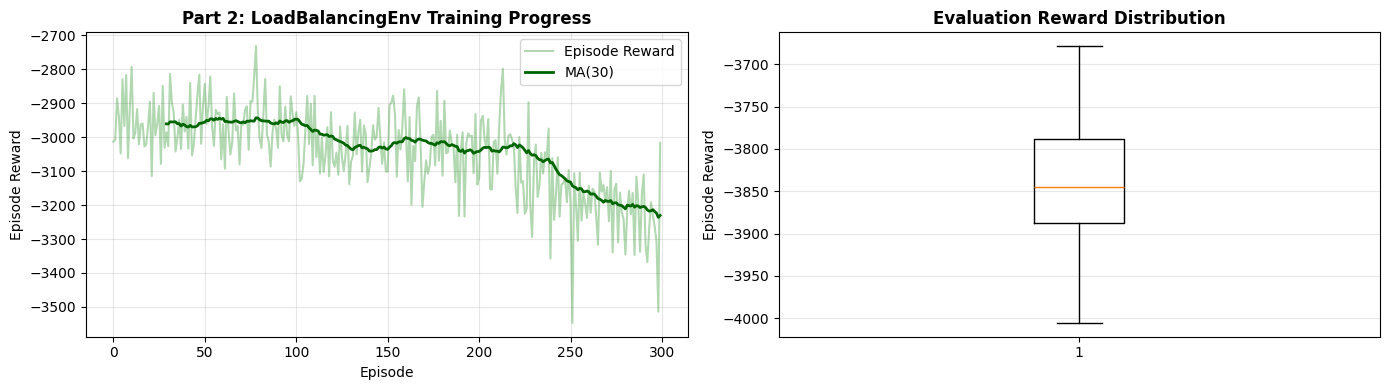

In [22]:
# ============================================================================
# Part 2 visualization
# ============================================================================
# Left plot: episode rewards + moving average
# Right plot: distribution of evaluation rewards

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: training trend
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='green')
ma_window = 30
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='darkgreen', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 2: LoadBalancingEnv Training Progress', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: evaluation spread
axes[1].boxplot(eval_rewards, vert=True)
axes[1].set_ylabel('Episode Reward')
axes[1].set_title('Evaluation Reward Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)  # Free figure memory

In [ ]:

# ============================================================================
# Part 2.4: Metrics environment + compare DQN vs Round Robin (100 episodes)
# ============================================================================

import os
import pandas as pd
from collections import deque

if 'agent2' not in globals():
    raise RuntimeError("Không tìm thấy agent2. Hãy chạy cell huấn luyện DQN (2.2) trước.")

class MetricsLoadBalancingEnv(gym.Env):
    """
    LoadBalancingEnv với state 5D và hai chế độ reward.
    State: [q0/C, q1/C, q2/C, demand/MAX_DEMAND, load_deviation_norm]
      - 3 queue norms: mức tải từng server
      - demand_norm: kích thước task sắp đến
      - load_dev_norm: std(q_norm) — mức mất cân bằng hiện tại (thay thế step_norm)
    """

    CAPACITY   = 100.0
    MIN_DEMAND =   5.0
    MAX_DEMAND =  20.0

    def __init__(self, num_servers=3, max_steps=300, reward_mode='v1'):
        super().__init__()
        self.num_servers = num_servers
        self.max_steps   = max_steps
        self.reward_mode = reward_mode
        self.action_space      = spaces.Discrete(num_servers)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(num_servers + 2,), dtype=np.float32
        )
        self.reset()

    # ── internal helpers ──────────────────────────────────────────────────
    def _reset_metrics(self):
        self.metrics = {
            'total_time':          0,
            'total_tasks_created': 0,
            'tasks_accepted':      0,
            'tasks_skipped':       0,
            'tasks_completed':     0,
            'total_reward':        0.0,
            'queue_sum':           0.0,
            'load_deviation_sum':  0.0,
            'server_selection':    [0] * self.num_servers,
        }

    def _get_state(self):
        q_norm        = self.queues / self.CAPACITY
        demand_norm   = self.current_demand / self.MAX_DEMAND
        load_dev_norm = float(np.std(q_norm))          # ∈ [0, ~0.5]
        return np.concatenate([q_norm, [demand_norm, load_dev_norm]]).astype(np.float32)

    # ── gym API ───────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.rng          = np.random.default_rng(seed)
        self.steps        = 0
        self.queues       = np.zeros(self.num_servers, dtype=np.float32)
        self.task_queues  = [deque() for _ in range(self.num_servers)]
        self.current_demand = float(self.rng.integers(self.MIN_DEMAND, self.MAX_DEMAND + 1))
        self._reset_metrics()
        return self._get_state(), {}

    def _compute_reward(self, action, accepted, pre_queues):       
        C = self.CAPACITY
        N = self.num_servers

        if self.reward_mode == 'v1':
            return -float(np.sum(self.queues)) / 100.0

        avg_pre_norm    = float(np.mean(pre_queues)) / C   # ∈ [0, 1]
        chosen_pre_norm = float(pre_queues[action])  / C   # ∈ [0, 1]
        routing_bonus   = avg_pre_norm - chosen_pre_norm   # ∈ [-1, +1]

        load_dev = float(np.std(self.queues / C))          # ∈ [0, ~0.5]

        avg_q_norm = float(np.mean(self.queues)) / C       # ∈ [0, 1]

        drop_pen = 0.5 if not accepted else 0.0

        reward = (
             0.4 * routing_bonus   
            -0.6 * load_dev        
            -0.2 * avg_q_norm      
            - drop_pen             
        )
        return float(np.clip(reward, -2.0, 1.0))

    def step(self, action):
        self.steps += 1
        self.metrics['total_time']          = self.steps
        self.metrics['total_tasks_created'] += 1
        self.metrics['server_selection'][action] += 1

        pre_queues = self.queues.copy()          # snapshot TRƯỚC khi cập nhật
        demand     = float(self.current_demand)

        accepted = False
        if self.queues[action] + demand <= self.CAPACITY:
            accepted = True
            self.metrics['tasks_accepted'] += 1
            self.task_queues[action].append(demand)
            self.queues[action] += demand
        else:
            self.metrics['tasks_skipped'] += 1

        # service: mỗi server xử lý tối đa 1 đơn vị mỗi bước
        for i in range(self.num_servers):
            remaining = 1.0
            while remaining > 1e-8 and self.task_queues[i]:
                current = self.task_queues[i][0]
                consume = min(current, remaining)
                current   -= consume
                remaining -= consume
                self.queues[i] -= consume
                if current <= 1e-8:
                    self.task_queues[i].popleft()
                    self.metrics['tasks_completed'] += 1
                else:
                    self.task_queues[i][0] = current

        total_queue = float(np.sum(self.queues))
        load_dev    = float(np.std(self.queues / self.CAPACITY))
        reward      = self._compute_reward(action, accepted, pre_queues, demand)

        self.metrics['total_reward']       += reward
        self.metrics['queue_sum']          += total_queue
        self.metrics['load_deviation_sum'] += load_dev

        self.current_demand = float(self.rng.integers(self.MIN_DEMAND, self.MAX_DEMAND + 1))

        terminated = False
        truncated  = self.steps >= self.max_steps
        return self._get_state(), reward, terminated, truncated, {}

    def get_episode_metrics(self):
        t   = max(1, self.metrics['total_time'])
        out = {
            'total_time':          self.metrics['total_time'],
            'total_tasks_created': self.metrics['total_tasks_created'],
            'tasks_accepted':      self.metrics['tasks_accepted'],
            'tasks_skipped':       self.metrics['tasks_skipped'],
            'tasks_completed':     self.metrics['tasks_completed'],
            'total_reward':        round(self.metrics['total_reward'],  4),
            'avg_queue_time':      round(self.metrics['queue_sum'] / (t * self.num_servers), 4),
            'load_deviation':      round(self.metrics['load_deviation_sum'] / t, 4),
        }
        for i in range(self.num_servers):
            out[f'server_{i}_freq'] = round(self.metrics['server_selection'][i] / t, 4)
        return out


# ── Helper policies ───────────────────────────────────────────────────────

class RoundRobinPolicy:
    def __init__(self, num_servers=3):
        self.num_servers = num_servers
        self.ptr = 0

    def reset(self):
        self.ptr = 0

    def select_action(self, state=None, training=False):
        action = self.ptr % self.num_servers
        self.ptr += 1
        return action


class Agent2On5DWrapper:
    """Dùng agent2 (3D state) trên env 5D bằng cách lấy 3 phần tử đầu."""
    def __init__(self, base_agent):
        self.base_agent = base_agent

    def select_action(self, state, training=False):
        state3 = np.array(state[:3], dtype=np.float32)
        return self.base_agent.select_action(state3, training=training)


# ── Evaluation + CSV helpers ──────────────────────────────────────────────

def evaluate_policy(policy_obj, env_factory, label='Policy', n_episodes=100, seed_offset=0):
    records = []
    for ep in range(n_episodes):
        env_eval = env_factory()
        state, _ = env_eval.reset(seed=2026 + seed_offset * 1000 + ep)
        if hasattr(policy_obj, 'reset'):
            policy_obj.reset()
        done = False
        while not done:
            action = policy_obj.select_action(state, training=False)
            state, _, terminated, truncated, _ = env_eval.step(action)
            done = terminated or truncated
        m = env_eval.get_episode_metrics()
        m['episode'] = ep + 1
        m['policy']  = label
        records.append(m)
    return pd.DataFrame(records)


def save_metrics_to_csv(df_a, df_b, out_dir='results_part2', tag='compare'):
    os.makedirs(out_dir, exist_ok=True)
    name_a   = str(df_a['policy'].iloc[0]).lower().replace(' ', '_')
    name_b   = str(df_b['policy'].iloc[0]).lower().replace(' ', '_')
    path_a   = os.path.join(out_dir, f'{name_a}_{tag}.csv')
    path_b   = os.path.join(out_dir, f'{name_b}_{tag}.csv')
    path_cmp = os.path.join(out_dir, f'comparison_{tag}.csv')
    df_a.to_csv(path_a, index=False)
    df_b.to_csv(path_b, index=False)
    metric_cols = [
        'total_time', 'total_tasks_created', 'tasks_accepted', 'tasks_skipped',
        'tasks_completed', 'total_reward', 'avg_queue_time', 'load_deviation',
        'server_0_freq', 'server_1_freq', 'server_2_freq',
    ]
    rows = []
    for col in metric_cols:
        rows.append({
            'Metric': col,
            'A_mean': round(df_a[col].mean(), 4),
            'A_std':  round(df_a[col].std(),  4),
            'B_mean': round(df_b[col].mean(), 4),
            'B_std':  round(df_b[col].std(),  4),
        })
    df_cmp = pd.DataFrame(rows)
    df_cmp.to_csv(path_cmp, index=False)
    return path_a, path_b, path_cmp, df_cmp


# ── 2.4: DQN_v1_basic vs RoundRobin (100 episodes, reward_mode='v1') ─────
print("\n2.4: So sánh DQN (cell 2.2) vs Round Robin trên reward v1")
print("-" * 60)
N_EPISODES_COMPARE = 100

rr_policy    = RoundRobinPolicy(num_servers=3)
dqn_v1_wrapper = Agent2On5DWrapper(agent2)
env_v1_factory = lambda: MetricsLoadBalancingEnv(num_servers=3, max_steps=300, reward_mode='v1')

df_dqn_v1_basic = evaluate_policy(dqn_v1_wrapper,  env_v1_factory, label='DQN_v1_basic', n_episodes=N_EPISODES_COMPARE)
df_rr_v1_basic  = evaluate_policy(rr_policy,        env_v1_factory, label='RoundRobin_v1', n_episodes=N_EPISODES_COMPARE)

path_a, path_b, path_cmp, df_cmp = save_metrics_to_csv(
    df_dqn_v1_basic, df_rr_v1_basic,
    out_dir='results_part2', tag='dqn_vs_roundrobin_v1_100eps',
)

print("\nBảng tóm tắt (A: DQN_v1_basic, B: RoundRobin_v1):")
print(df_cmp.to_string(index=False))
print("\nĐã lưu file:")
print(f"  {path_a}")
print(f"  {path_b}")
print(f"  {path_cmp}")



2.4: So sánh DQN (cell 2.2) vs Round Robin trên reward v1
------------------------------------------------------------

Bảng tóm tắt (A: DQN_v1_basic, B: RoundRobin_v1):
             Metric    A_mean  A_std    B_mean  B_std
         total_time  300.0000 0.0000  300.0000 0.0000
total_tasks_created  300.0000 0.0000  300.0000 0.0000
     tasks_accepted   50.3100 2.0680  123.3900 3.6650
      tasks_skipped  249.6900 2.0680  176.6100 3.6650
    tasks_completed   36.2500 1.6780   89.9900 3.1318
       total_reward -278.5915 0.9665 -784.5875 4.7609
     avg_queue_time   30.9546 0.1074   87.1764 0.5290
     load_deviation    0.4378 0.0015    0.0339 0.0025
      server_0_freq    1.0000 0.0000    0.3333 0.0000
      server_1_freq    0.0000 0.0000    0.3333 0.0000
      server_2_freq    0.0000 0.0000    0.3333 0.0000

Đã lưu file:
  results_part2\dqn_v1_basic_dqn_vs_roundrobin_v1_100eps.csv
  results_part2\roundrobin_v1_dqn_vs_roundrobin_v1_100eps.csv
  results_part2\comparison_dqn_vs_roundrobin

### 2.5: Reward v2 + 5D state + Multi-seed DQN Training

In [ ]:

# ============================================================================
# 2.5: Train DQN với reward v2 (state 5D, multi-seed) + đánh giá tác động
# ============================================================================

import time

class TinyDQNNetwork(nn.Module):
    """MLP 5→128→64→3 cho state 5D."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 3),
        )
    def forward(self, x):
        return self.net(x)


class TinyDQNAgent:
    def __init__(self, learning_rate=5e-4, gamma=0.99):
        self.gamma         = gamma
        self.epsilon       = 1.0
        self.epsilon_min   = 0.01
        self.epsilon_decay = 0.995     

        self.q_network      = TinyDQNNetwork().to(device)
        self.target_network = TinyDQNNetwork().to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer     = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn       = nn.SmoothL1Loss()
        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.update_counter = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, 2)
        state_t = torch.tensor(np.array(state, dtype=np.float32), device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_t)
        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(
            np.array(state,      dtype=np.float32),
            action,
            reward,
            np.array(next_state, dtype=np.float32),
            done,
        )

    def train_step(self, batch_size=64):
        if len(self.replay_buffer) < batch_size:
            return
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)
        q_pred = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q  = self.target_network(next_states).max(dim=1)[0]
            q_target = rewards + self.gamma * next_q * (1 - dones)
        loss = self.loss_fn(q_pred, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# ── Config ────────────────────────────────────────────────────────────────
SEEDS_V2       = [42, 7, 123]
NUM_EPISODES_V2 = 500
BATCH_SIZE_V2   = 64

print('\n2.5: Huấn luyện lại DQN với reward v2 (balanced: routing + load_dev + avg_queue)')
print('-' * 70)
print('Network : 5→128→64→3')
print('Reward  : 0.4*routing_bonus − 0.6*load_dev − 0.2*avg_q − drop_pen(0.5)')
print('State   : [q0/C, q1/C, q2/C, demand/MAX, load_dev_norm]')
print(f'Config  : episodes={NUM_EPISODES_V2}, batch={BATCH_SIZE_V2}, lr=5e-4, eps_decay=0.995')
print()

v2_curves        = {}
trained_v2_agents = {}

for seed in SEEDS_V2:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env_train_v2 = MetricsLoadBalancingEnv(num_servers=3, max_steps=300, reward_mode='v2')
    agent_seed   = TinyDQNAgent(learning_rate=5e-4, gamma=0.99)
    rewards_seed = []
    t0 = time.time()

    for ep in range(NUM_EPISODES_V2):
        state, _ = env_train_v2.reset(seed=seed * 10000 + ep)
        done      = False
        ep_reward = 0.0

        while not done:
            action = agent_seed.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env_train_v2.step(action)
            done = terminated or truncated
            agent_seed.store_transition(state, action, reward, next_state, done)
            agent_seed.train_step(BATCH_SIZE_V2)
            ep_reward += reward
            state = next_state

        agent_seed.decay_epsilon()
        rewards_seed.append(ep_reward)

        if (ep + 1) % 100 == 0:
            avg100 = np.mean(rewards_seed[-100:])
            print(f'  [seed={seed}] ep {ep+1:4d}/{NUM_EPISODES_V2} | '
                  f'avg(last100)={avg100:+.3f} | eps={agent_seed.epsilon:.3f}')

    v2_curves[seed]         = rewards_seed
    trained_v2_agents[seed] = agent_seed
    print(f'  seed={seed} ✓  {time.time()-t0:.1f}s | '
          f'final avg(last100)={np.mean(rewards_seed[-100:]):+.3f}\n')

# Representative agent (seed=42)
agent_v2 = trained_v2_agents[42]

# Aggregate training curves
v2_rewards_matrix = np.array([v2_curves[s] for s in SEEDS_V2], dtype=np.float32)
v2_rewards_mean   = v2_rewards_matrix.mean(axis=0)
v2_rewards_std    = v2_rewards_matrix.std(axis=0)

# ── Evaluate DQN_v2 vs RoundRobin (v2 env) ───────────────────────────────
N_COMPARE_V2  = 100
rr_policy_v2  = RoundRobinPolicy(num_servers=3)
env_v2_factory = lambda: MetricsLoadBalancingEnv(num_servers=3, max_steps=300, reward_mode='v2')

df_dqn_v2 = evaluate_policy(agent_v2,    env_v2_factory, label='DQN_v2',       n_episodes=N_COMPARE_V2)
df_rr_v2  = evaluate_policy(rr_policy_v2, env_v2_factory, label='RoundRobin_v2', n_episodes=N_COMPARE_V2)

path_v2_a, path_v2_b, path_v2_cmp, df_cmp_v2 = save_metrics_to_csv(
    df_dqn_v2, df_rr_v2,
    out_dir='results_part2', tag='dqn_v2_vs_roundrobin_100eps',
)
print('Summary Table (A: DQN_v2, B: RoundRobin_v2):')
print(df_cmp_v2.to_string(index=False))
print(f'\nSaved: {path_v2_cmp}')

# ── 3-way impact: DQN_v2 (mới) vs DQN_v1_basic (cũ) vs RoundRobin ───────
print('\n' + '='*70)
print('Đánh giá tác động reward v2: DQN_v2 (mới) vs DQN_v1_basic (cũ) vs RoundRobin')
print('(tất cả chạy trên môi trường reward_mode=v2 để so sánh công bằng)')
print('='*70)

dqn_v1_wrapper_impact = Agent2On5DWrapper(agent2)
rr_policy_impact      = RoundRobinPolicy(num_servers=3)

df_dqn_v1_impact = evaluate_policy(dqn_v1_wrapper_impact, env_v2_factory,
                                    label='DQN_v1_basic', n_episodes=N_COMPARE_V2)
df_rr_impact     = evaluate_policy(rr_policy_impact,       env_v2_factory,
                                    label='RoundRobin',    n_episodes=N_COMPARE_V2)

metric_cols_impact = [
    'tasks_accepted', 'tasks_skipped', 'avg_queue_time',
    'load_deviation', 'server_0_freq', 'server_1_freq', 'server_2_freq', 'total_reward',
]
rows_impact = []
for col in metric_cols_impact:
    rows_impact.append({
        'Metric':              col,
        'DQN_v2 (mới)':       round(df_dqn_v2[col].mean(),       4),
        'DQN_v1_basic (cũ)':  round(df_dqn_v1_impact[col].mean(), 4),
        'RoundRobin':          round(df_rr_impact[col].mean(),     4),
    })

df_impact = pd.DataFrame(rows_impact)
print(df_impact.to_string(index=False))

impact_path = os.path.join('results_part2', 'impact_dqnv2_vs_old_3way.csv')
df_impact.to_csv(impact_path, index=False)
print(f'\nĐã lưu: {impact_path}')



2.5: Huấn luyện lại DQN với reward v2 (balanced: routing + load_dev + avg_queue)
----------------------------------------------------------------------
Network : 5→128→64→3
Reward  : 0.4*routing_bonus − 0.6*load_dev − 0.2*avg_q − drop_pen(0.5)
State   : [q0/C, q1/C, q2/C, demand/MAX, load_dev_norm]
Config  : episodes=500, batch=64, lr=5e-4, eps_decay=0.995

  [seed=42] ep  100/500 | avg(last100)=-147.393 | eps=0.606
  [seed=42] ep  200/500 | avg(last100)=-144.142 | eps=0.367
  [seed=42] ep  300/500 | avg(last100)=-142.514 | eps=0.222
  [seed=42] ep  400/500 | avg(last100)=-141.924 | eps=0.135
  [seed=42] ep  500/500 | avg(last100)=-141.546 | eps=0.082
  seed=42 ✓  186.6s | final avg(last100)=-141.546

  [seed=7] ep  100/500 | avg(last100)=-147.704 | eps=0.606
  [seed=7] ep  200/500 | avg(last100)=-144.413 | eps=0.367
  [seed=7] ep  300/500 | avg(last100)=-142.736 | eps=0.222
  [seed=7] ep  400/500 | avg(last100)=-141.913 | eps=0.135
  [seed=7] ep  500/500 | avg(last100)=-141.971 | eps

### 2.6: Visualized Reward version 2

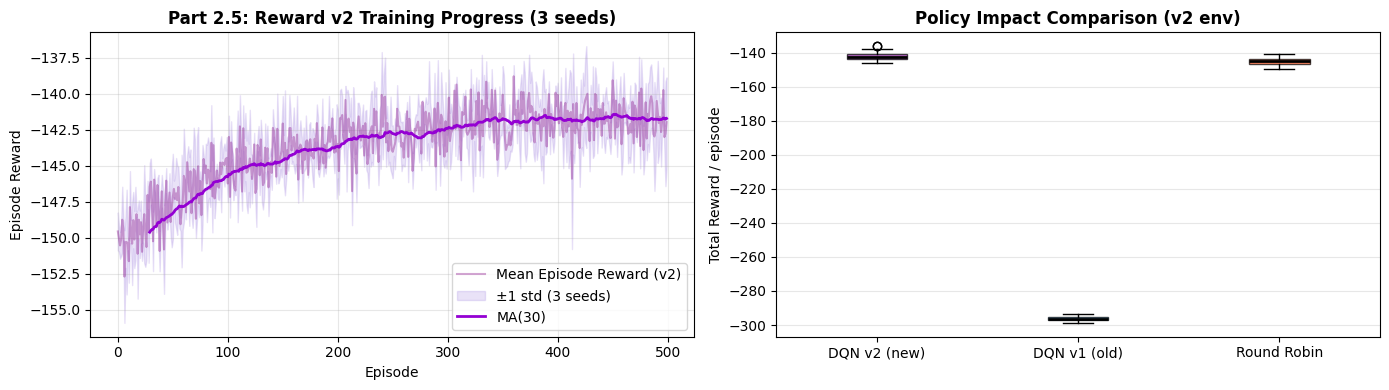

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: mean training curve across seeds + MA(30)
axes[0].plot(v2_rewards_mean, alpha=0.35, label='Mean Episode Reward (v2)', color='purple')
axes[0].fill_between(
    range(len(v2_rewards_mean)),
    v2_rewards_mean - v2_rewards_std,
    v2_rewards_mean + v2_rewards_std,
    alpha=0.2, color='mediumpurple', label='±1 std (3 seeds)'
)
ma_window = 30
ma_v2 = np.convolve(v2_rewards_mean, np.ones(ma_window) / ma_window, mode='valid')
axes[0].plot(range(ma_window - 1, len(v2_rewards_mean)), ma_v2,
             label=f'MA({ma_window})', color='darkviolet', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 2.5: Reward v2 Training Progress (3 seeds)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: 3-way boxplot — DQN_v2 (mới) vs DQN_v1_basic (cũ) vs RoundRobin
data_box   = [df_dqn_v2['total_reward'].values,
              df_dqn_v1_impact['total_reward'].values,
              df_rr_impact['total_reward'].values]
labels_box = ['DQN v2 (new)', 'DQN v1 (old)', 'Round Robin']
colors_box = ['#9C27B0', '#2196F3', '#FF5722']
bp = axes[1].boxplot(data_box, tick_labels=labels_box, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, clr in zip(bp['boxes'], colors_box):
    patch.set_facecolor(clr)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Total Reward / episode')
axes[1].set_title('Policy Impact Comparison (v2 env)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)


## CONGRATULATIONS TEAM!

Congratulations on completing Lab 03.2 - Introduction to Deep Q-Network!

You have successfully:
- Designed and implemented custom Gymnasium environments (VacuumCleanerEnv, LoadBalancingEnv)
- Trained DQN agents on multiple custom environments
- Learned how to use Stable-Baselines3 for production-ready RL
- Compared manual vs. library-based implementations
- Evaluated agents and visualized training progress

You now have the skills to apply DQN to real-world problems!

References: https://gymnasium.farama.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026